🌊 Melatih Agen 'Operator Tandon Air'...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -426     |
| time/              |          |
|    fps             | 4738     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 100        |
|    ep_rew_mean          | -349       |
| time/                   |            |
|    fps                  | 3356       |
|    iterations           | 2          |
|    time_elapsed         | 1          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.01086324 |
|    clip_fraction        | 0.0372     |
|    clip_range           | 0.2   

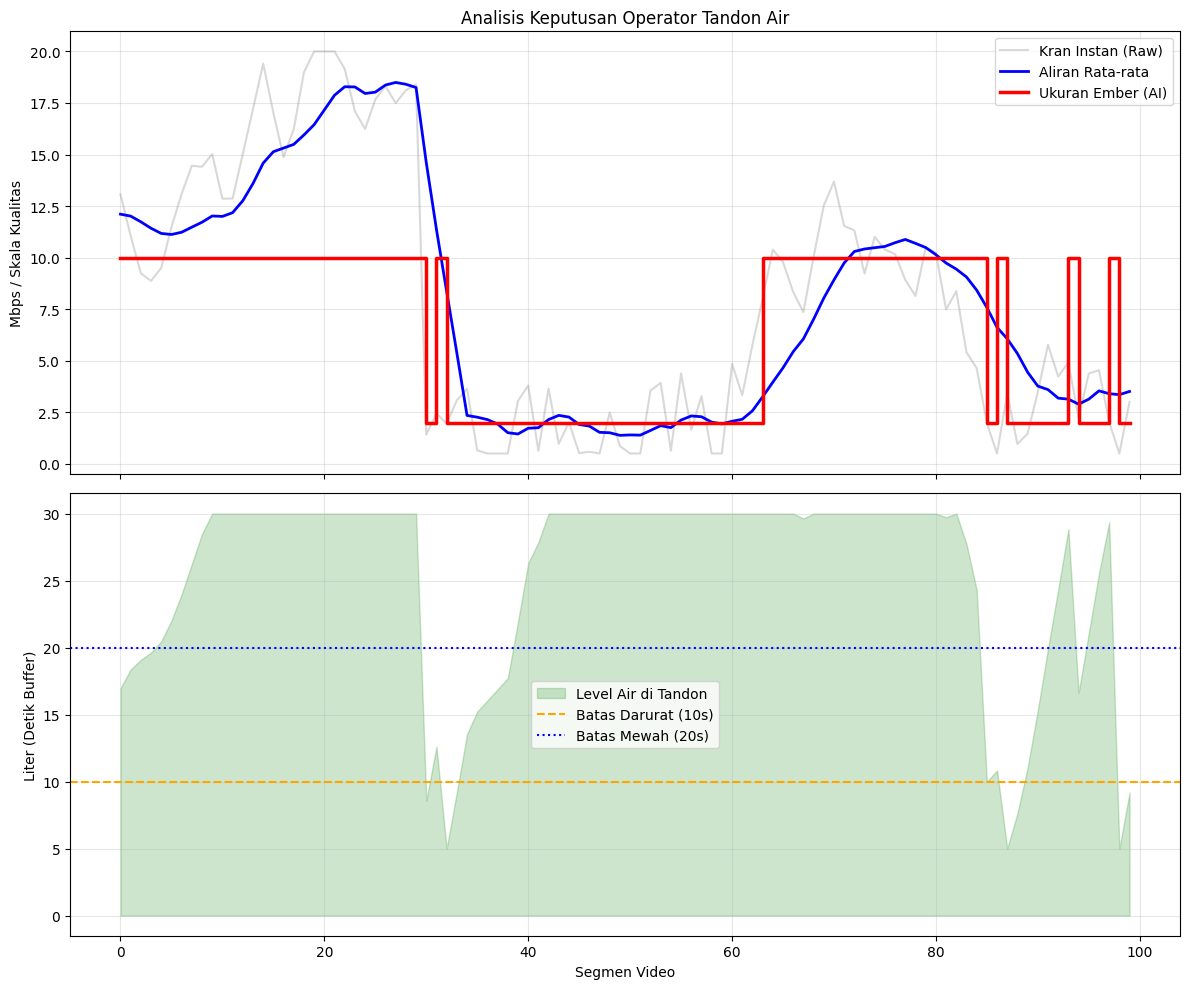

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

class TandonStreamingEnv(gym.Env):
    """
    Simulator Lingkungan Video Streaming berdasarkan Analogi Operator Tandon Air.
    Strategi: 
    - Buffer < 10s: Darurat (Safety First)
    - Buffer 10-20s: Stabil (Keseimbangan)
    - Buffer > 20s: Mewah (Kualitas Maksimal)
    """
    def __init__(self, window_size=10):
        super(TandonStreamingEnv, self).__init__()
        
        # Konfigurasi Bitrate (0=Low, 1=Mid, 2=High)
        self.bitrates = [0.5, 2.5, 8.0]
        self.action_space = spaces.Discrete(3)
        
        # Observasi: [Buffer, Avg_Throughput, Last_Action, Buffer_Trend, TP_Trend]
        # Buffer_Trend: >0 mengisi, <0 menguras
        # TP_Trend: >0 internet naik, <0 internet turun
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, -5, -5]),
            high=np.array([30, 20, 2, 5, 5]),
            dtype=np.float32
        )
        
        self.window_size = window_size
        self.tp_history = deque(maxlen=window_size)
        self.buffer_history = deque(maxlen=2)
        
        self.state = None
        self.max_steps = 100
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # Inisialisasi internet awal (12 Mbps)
        initial_tp = 12.0
        for _ in range(self.window_size):
            self.tp_history.append(initial_tp)
        
        self.buffer_history.clear()
        self.buffer_history.append(15.0) # Start di kondisi stabil
        
        # State awal: [Buffer, Avg_TP, Action, Buf_Trend, TP_Trend]
        self.state = np.array([15.0, initial_tp, 1.0, 0.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, _, last_action, _, last_tp_avg = self.state
        chosen_bitrate = self.bitrates[action]
        
        # 1. Simulasi Realitas (Kran Air / Throughput dengan Noise)
        # Internet berfluktuasi secara acak namun kontinu
        raw_tp = np.clip(self.tp_history[-1] + np.random.uniform(-3.0, 3.0), 0.5, 20.0)
        self.tp_history.append(raw_tp)
        
        # Hitung Rata-rata Aliran (Smoothing)
        avg_tp = sum(self.tp_history) / len(self.tp_history)
        tp_trend = avg_tp - last_tp_avg
        
        # 2. Dinamika Tandon (Buffer)
        seg_duration = 5.0
        # Waktu download nyata berdasarkan throughput instan
        download_time = (chosen_bitrate * seg_duration / (raw_tp + 0.1))
        
        # Apakah tandon kering sebelum download selesai?
        stalling = max(0, download_time - buffer)
        
        # Update level tandon (dikuras selama download, diisi 5 detik setelah selesai)
        new_buffer = max(0, buffer - download_time) + seg_duration
        new_buffer = min(new_buffer, 30.0)
        
        # Hitung tren tandon (mengisi atau menguras?)
        buffer_trend = new_buffer - buffer
        
        # 3. LOGIKA REWARD (Berdasarkan strategi_ai_streaming.md)
        # Reward Dasar = Kualitas * 1.0
        reward = chosen_bitrate * 1.0
        
        # Penalti Plin-plan (Switching) * 0.5
        switching_penalty = abs(action - last_action) * 0.5
        reward -= switching_penalty
        
        # Penalti Tandon Kering (Stalling) * 50.0
        if stalling > 0:
            reward -= 50.0
            
        # Penalti "PELIT" (Aturan 3.3)
        # Menghukum jika pilih Low saat internet kencang (>10Mbps) dan tandon penuh (>20s)
        if action == 0 and avg_tp > 10.0 and buffer > 20.0:
            reward -= 10.0
            
        # Insentif Keselamatan (Aturan 2.A)
        # Jika buffer < 10 dan pilih High, beri hukuman risiko tambahan
        if buffer < 10.0 and action == 2:
            reward -= 20.0

        # Update State untuk langkah berikutnya
        self.state = np.array([new_buffer, avg_tp, float(action), buffer_trend, tp_trend], dtype=np.float32)
        
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {"raw_tp": raw_tp}

def run_training_and_eval():
    print("🌊 Melatih Agen 'Operator Tandon Air'...")
    env = TandonStreamingEnv()
    
    # Latih model selama 100.000 langkah agar matang
    model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003, ent_coef=0.01)
    model.learn(total_timesteps=100000)
    
    # --- EVALUASI ---
    obs, _ = env.reset()
    history = []
    
    for i in range(100):
        # Skenario internet: Stabil kencang, lalu drop parah, lalu naik lagi
        if 30 <= i <= 60:
            # Simulasi kran air mampet mendadak
            env.tp_history.append(np.random.uniform(1.0, 3.0))
            
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        
        history.append({
            'Langkah': i,
            'Internet': info['raw_tp'],
            'Rata_Rata': obs[1],
            'Tandon_Buffer': obs[0],
            'Kualitas_Ember': action
        })

    df = pd.DataFrame(history)
    
    # --- VISUALISASI ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Grafik Jaringan vs Keputusan
    ax1.plot(df['Langkah'], df['Internet'], label='Kran Instan (Raw)', color='gray', alpha=0.3)
    ax1.plot(df['Langkah'], df['Rata_Rata'], label='Aliran Rata-rata', color='blue', linewidth=2)
    ax1.step(df['Langkah'], df['Kualitas_Ember'] * 4 + 2, label='Ukuran Ember (AI)', color='red', linewidth=2.5)
    ax1.set_title("Analisis Keputusan Operator Tandon Air")
    ax1.set_ylabel("Mbps / Skala Kualitas")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Grafik Isi Tandon
    ax2.fill_between(df['Langkah'], df['Tandon_Buffer'], color='green', alpha=0.2, label='Level Air di Tandon')
    ax2.axhline(y=10, color='orange', linestyle='--', label='Batas Darurat (10s)')
    ax2.axhline(y=20, color='blue', linestyle=':', label='Batas Mewah (20s)')
    ax2.set_ylabel("Liter (Detik Buffer)")
    ax2.set_xlabel("Segmen Video")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_training_and_eval()